In [80]:
import os
import random
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch.nn.functional as F

In [81]:
# from google.colab import drive
# drive.mount('/content/drive')
# base_dir = '/content/drive/My Drive/Colab Notebooks/'
base_dir = ''

In [82]:
# 1. Original IPN Hand dataset (videos)
ipn_path = kagglehub.dataset_download("soumicksarker/ipn-hand-dataset")
print("IPN dataset:", ipn_path)

# 2. Your segmentation masks dataset
seg_path = kagglehub.dataset_download("johnsonyang123321/ipn-hand-data-segmented")
seg_dir = os.path.join(seg_path, "segment")  # should now exist properly
print("Segmentation masks dir:", seg_dir)
print("Sample sequences:", os.listdir(seg_dir)[:5])

IPN dataset: C:\Users\billa\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7
Segmentation masks dir: C:\Users\billa\.cache\kagglehub\datasets\johnsonyang123321\ipn-hand-data-segmented\versions\1\segment
Sample sequences: ['segment']


Segmentation sequences available: ['1CM1_1_R__217', '1CM1_1_R__218', '1CM1_1_R__219', '1CM1_1_R__220', '1CM1_2_R__221', '1CM1_2_R__222', '1CM1_2_R__223', '1CM1_2_R__224', '1CM1_3_R__225', '1CM1_3_R__226']
Selected sequence: 4CM11_16_R__212
Extracted 5 frames from 4CM11_16_R__212.avi
Frame 0 shape: (256, 256, 3), Mask 0 shape: (256, 256)
Frame 1 shape: (256, 256, 3), Mask 1 shape: (256, 256)
Frame 2 shape: (256, 256, 3), Mask 2 shape: (256, 256)
Frame 3 shape: (256, 256, 3), Mask 3 shape: (256, 256)
Frame 4 shape: (256, 256, 3), Mask 4 shape: (256, 256)


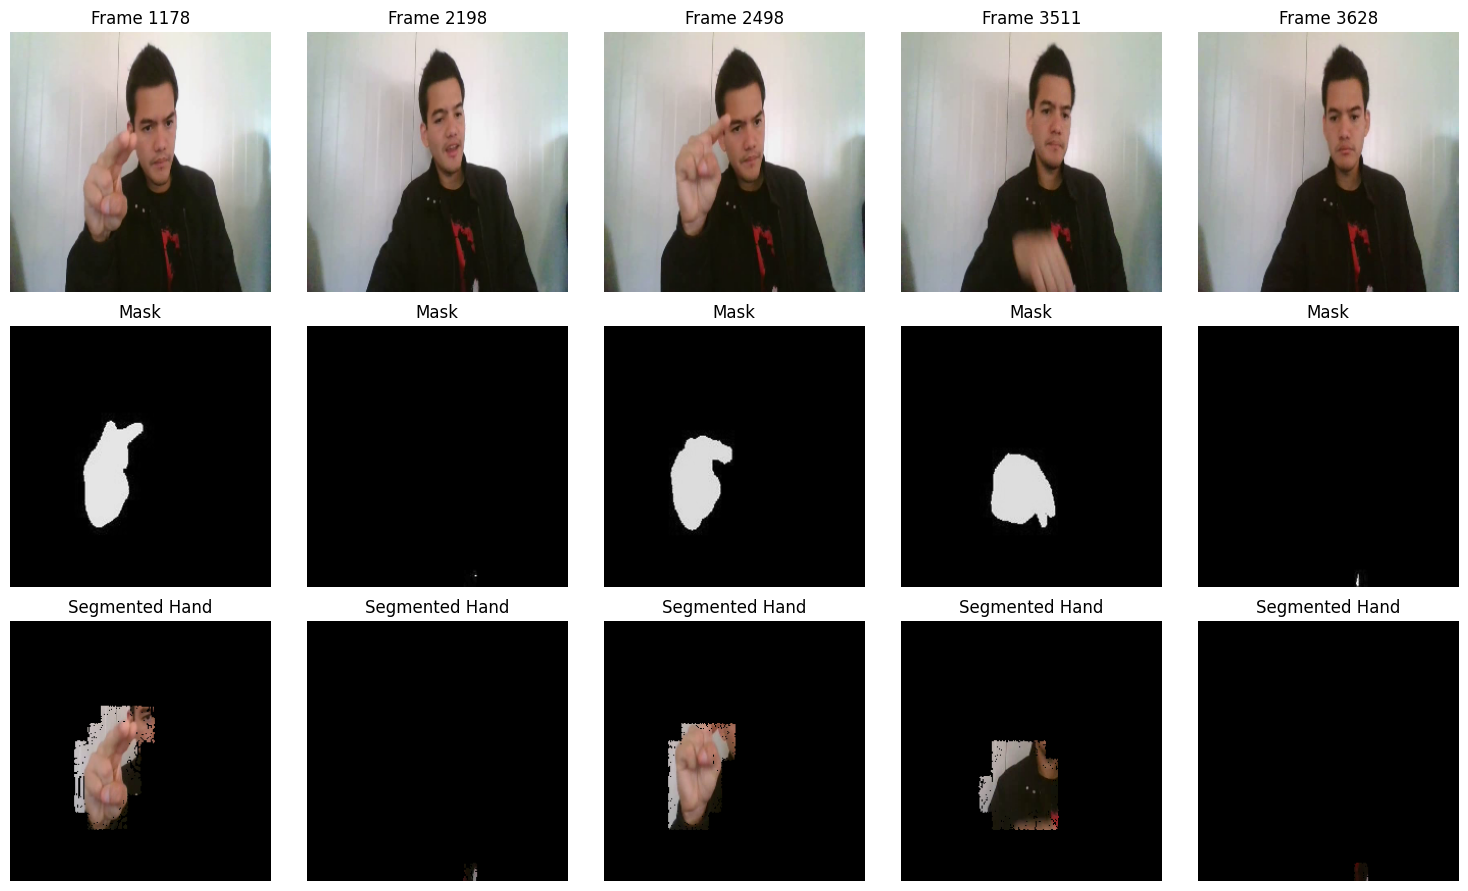

In [83]:
# --- Paths ---
videos_dir = os.path.join(ipn_path, "videos/videos")  # raw video files
seg_dir = os.path.join(seg_path, "segment/segment")   # segmentation sequences

# --- 1. List actual segmentation sequence folders ---
seg_sequences = [d for d in os.listdir(seg_dir) if os.path.isdir(os.path.join(seg_dir, d))]
print("Segmentation sequences available:", seg_sequences[:10])

if not seg_sequences:
    raise ValueError("No segmentation sequences found!")

# --- 2. Pick a random segmentation sequence ---
seq_name = random.choice(seg_sequences)
print("Selected sequence:", seq_name)

# --- 3. Find the corresponding video ---
video_file = seq_name + ".avi"
video_path = os.path.join(videos_dir, video_file)
if not os.path.exists(video_path):
    raise ValueError(f"Video {video_file} not found in videos folder!")

# --- 4. Extract a few frames from the video ---
cap = cv2.VideoCapture(video_path)
frames = []
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Pick 5 random frames
sample_indices = sorted(random.sample(range(frame_count), min(5, frame_count)))

idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if idx in sample_indices:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Resize frame to 256x256
        frame_rgb = cv2.resize(frame_rgb, (256, 256))
        frames.append(frame_rgb)
    idx += 1
cap.release()
print(f"Extracted {len(frames)} frames from {video_file}")

# --- 5. Load corresponding segmentation masks ---
mask_seq_path = os.path.join(seg_dir, seq_name)
mask_files = sorted(os.listdir(mask_seq_path))
masks = []
for i in sample_indices:
    m = Image.open(os.path.join(mask_seq_path, mask_files[i])).convert("L")
    # Resize mask to 256x256
    m = m.resize((256, 256))
    mask_array = np.array(m)
    masks.append(mask_array)

# --- 5b. Print shapes for verification ---
for i, (f, m) in enumerate(zip(frames, masks)):
    print(f"Frame {i} shape: {f.shape}, Mask {i} shape: {m.shape}")

# --- 6. Display frames, masks, and segmented hands ---
plt.figure(figsize=(15, 9))
for i, (f, m) in enumerate(zip(frames, masks)):
    # Original frame
    plt.subplot(3, len(frames), i + 1)
    plt.imshow(f)
    plt.title(f"Frame {sample_indices[i]}")
    plt.axis("off")

    # Mask
    plt.subplot(3, len(frames), len(frames) + i + 1)
    plt.imshow(m, cmap='gray')
    plt.title("Mask")
    plt.axis("off")

    # Segmented hand
    segmented = f.copy()
    segmented[m == 0] = 0  # zero out background
    plt.subplot(3, len(frames), 2*len(frames) + i + 1)
    plt.imshow(segmented)
    plt.title("Segmented Hand")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [84]:
def read_annotations(path):
    with open(path, 'r') as f:
        annots = []
        for idx, line in enumerate(f):
            if idx > 0:
                # Parse annotations and convert frame info into ints
                info = line.split(',')
                for i in range(2, len(info)):
                    info[i] = int(info[i])
                annots.append(info)
    return annots

In [85]:
class IPNDataPreProcessor:
    def __init__(self, annots, vid_path, seg_dir, transform = None):
        self.videos_path = vid_path
        self.seg_path = seg_dir
        
        self.annots = annots
        self.n = len(annots)
        self.videos_path = vid_path
        self.annots = annots
        self.transform = transform

        # Constants
        self.min_frames = 5
        self.num_frames = 210

        self.TARGET_SIZE = (256, 256)

        
    def __len__(self):
        return len(self.annots)

    def get_frames(self, video_name, start_frame, end_frame):
        video_path = os.path.join(self.videos_path, video_name + ".avi")


        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        if not cap.isOpened():
            raise FileNotFoundError(f"Video file not found: {video_path}")
    
        frames = []
        masks = []

        for frame_i in range(start_frame, end_frame):

            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mask_idx = frame_i - start_frame + 1
            mask_file = f"{video_name}_{mask_idx:06d}.jpg"
            mask_full_path = os.path.join(self.seg_path, video_name, mask_file)

            if not os.path.exists(mask_full_path):
                raise FileNotFoundError(mask_full_path)
            mask = cv2.imread(mask_full_path, cv2.IMREAD_GRAYSCALE)

            # resize frame sizes to match
            if frame.shape[:2] == mask.shape[:2]:
                frames.append(frame)
                masks.append(mask)
            else:
                frame = cv2.resize(frame, self.TARGET_SIZE)
                mask = cv2.resize(mask, self.TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
                frames.append(frame)
                masks.append(mask)

        cap.release()

        return frames, masks

    def __getitem__(self, idx):
        info = self.annots[idx]
        video_name, label, label_id, start_frame, end_frame, num_frames = info
        frames, masks = self.get_frames(video_name, start_frame, end_frame)

        # # Pad/truncate to fixed length
        frames = self.pad_sequence(frames, self.num_frames)
        masks = self.pad_sequence(masks, self.num_frames)

        # Convert to tensors
        frames = torch.tensor(np.stack(frames)).permute(0,3,1,2).float()
        masks = torch.tensor(np.stack(masks)).long()

        return frames, masks, label_id
    
    def pad_sequence(self, seq, target_len, pad_value=0):
        seq_len = len(seq)
        if seq_len >= target_len:
            return seq[:target_len]
        else:
            padding = [np.zeros_like(seq[0])]* (target_len - seq_len)
            return seq + padding


In [86]:
# -----------------------------
# 1. SETUP PATHS
# -----------------------------
videos_dir = os.path.join(ipn_path, "videos/videos")
seg_dir    = os.path.join(seg_path, "segment/segment")

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# 2. DATA
# -----------------------------
transform = T.Compose([
    T.ToTensor(),
    T.Resize((256,256))
])


annotations_path = os.path.join(ipn_path, "annotations/annotations")

train_annots = read_annotations(os.path.join(annotations_path, "Annot_TrainList.txt"))

train_dataset = IPNDataPreProcessor(
    train_annots, 
    videos_dir,
    seg_dir,
    transform=transform,
)

loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Print the input and output shapes and label
for img, mask, label in loader:
    print(img.shape, mask.shape, label)
    break



torch.Size([1, 210, 3, 256, 256]) torch.Size([1, 210, 256, 256]) tensor([10])


In [87]:
# --- CNN Encoder ---
class CNNEncoder(nn.Module):
    def __init__(self, out_features=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 256->128
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 128->64
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 64->32
            nn.ReLU(),
            nn.Conv2d(128, out_features, kernel_size=3, stride=2, padding=1), # 32->16
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)  # [B, out_features, H', W']

# --- CNN Decoder ---
class CNNDecoder(nn.Module):
    def __init__(self, hidden_size=1024, output_channels=1, Hf=16, Wf=16):
        super().__init__()
        self.fc = nn.Linear(hidden_size, 128*Hf*Wf)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), #16->32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  #32->64
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  #64->128
            nn.ReLU(),
            nn.ConvTranspose2d(16, output_channels, kernel_size=4, stride=2, padding=1), #128->256
        )
        self.Hf = Hf
        self.Wf = Wf

    def forward(self, x):
        B, S, H = x.shape
        x = self.fc(x)               # [B*S, 128*Hf*Wf]
        x = x.reshape(B*S, 128, self.Hf, self.Wf)
        x = self.decoder(x)
        x = x.reshape(B, S, 256, 256)
        return x

# --- Full RNN Video Model ---
class RNNVideoModel(nn.Module):
    def __init__(self, sequence_length=210):
        super().__init__()
        self.encoder = CNNEncoder(out_features=128)
        self.sequence_length = sequence_length
        self.rnn = nn.LSTM(
            input_size=128*16*16, 
            hidden_size=1024, 
            num_layers=2, 
            batch_first=True
        )
        self.decoder = CNNDecoder(hidden_size=1024, Hf=16, Wf=16)

    def forward(self, x):
        B, S, C, H, W = x.shape
        x_enc = x.reshape(B*S, C, H, W)      # Flatten batch and sequence
        features = self.encoder(x_enc)     # [B*S, F, Hf, Wf]
        F, Hf, Wf = features.shape[1:]
        features = features.reshape(B, S, F*Hf*Wf)  # [B, S, F*Hf*Wf]

        rnn_out, _ = self.rnn(features)   # [B, S, hidden_size]
        out = self.decoder(rnn_out)       # [B, S, 256, 256]
        return out

In [89]:
# load model and save path
model = RNNVideoModel().to(device)

save_path = os.path.join(base_dir, "models", "hand_seg_model_video.pth")

TRAIN_NEW_MODEL = True   # ⬅ set True to train, False to load

if TRAIN_NEW_MODEL:
    epochs = 15
    lr = 1e-3

    # criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for imgs, masks, _ in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            masks = (masks > 0).float()
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    # Save trained model
    plt.figure(figsize=(6,4))
    plt.plot(range(1, epochs+1), loss_history, marker='o')
    plt.title("Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
    torch.save(model.state_dict(), save_path)
    print(f"✅ Saved trained model to: {save_path}")

else:
    # Load existing model
    print("📂 Loading model from storage...")

    if not os.path.exists(save_path):
        raise FileNotFoundError(
            f"The file {save_path} does NOT exist.\n"
            f"Set TRAIN_NEW_MODEL = True to train a new model first."
        )

    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    
    print("✅ Loaded saved model successfully.")

KeyboardInterrupt: 

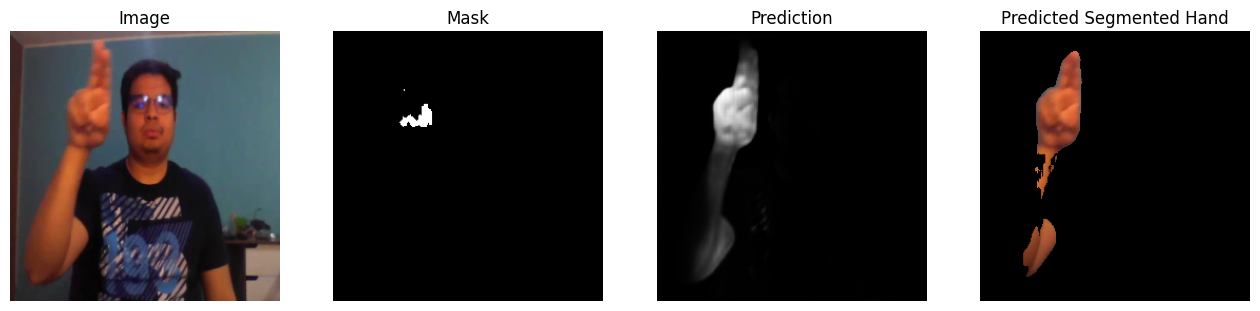

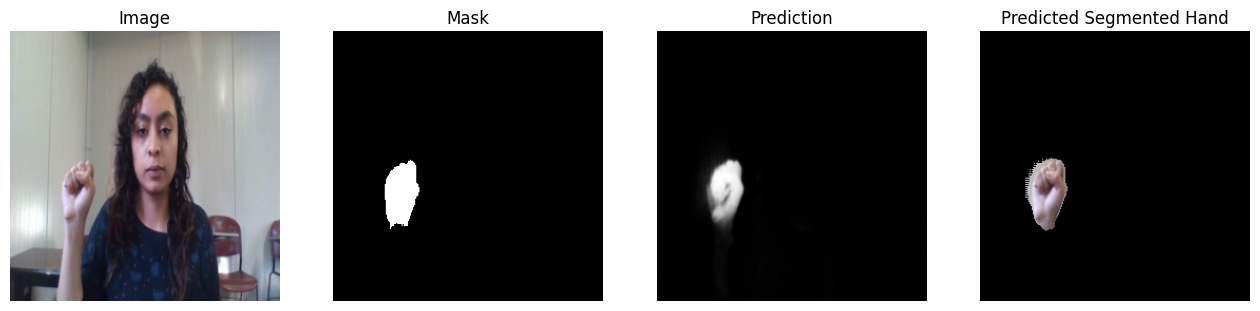

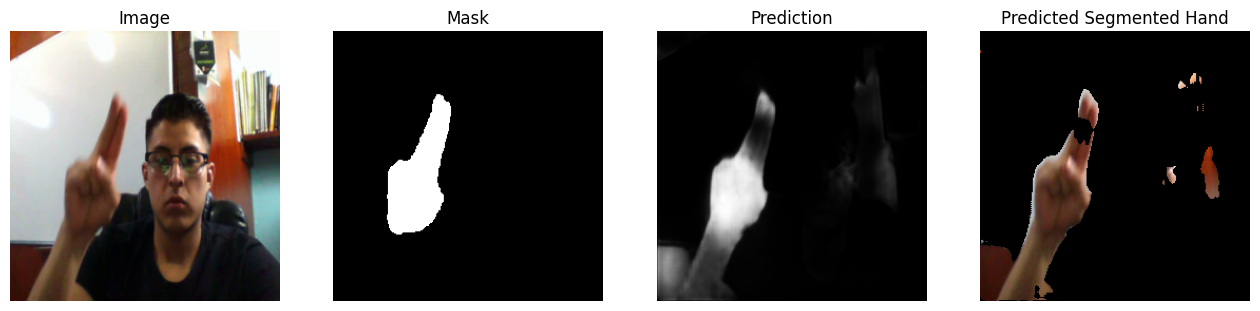

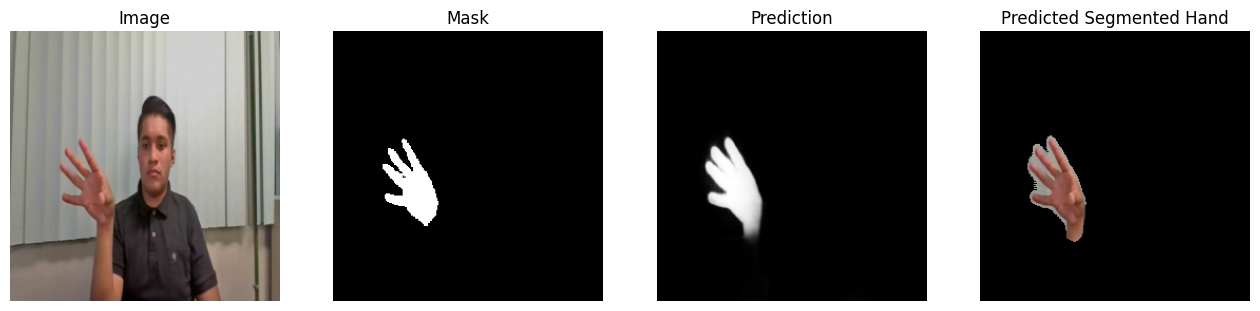

In [ ]:
model.eval()
with torch.no_grad():
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = model(imgs)

for i in range(min(4, imgs.size(0))):
    plt.figure(figsize=(16,4))

    # Original image
    plt.subplot(1,4,1)
    plt.imshow(imgs[i].cpu().permute(1,2,0))
    plt.title("Image")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1,4,2)
    plt.imshow(masks[i,0].cpu(), cmap='gray')
    plt.title("Mask")
    plt.axis("off")

    # Predicted mask
    pred_mask = preds[i,0].cpu()
    plt.subplot(1,4,3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    # Segmented predicted hand
    pred_mask_bin = (pred_mask > 0.1).float()   # threshold mask
    segmented = imgs[i].cpu() * pred_mask_bin   # apply mask
    segmented = segmented.permute(1,2,0)         # CHW → HWC

    plt.subplot(1,4,4)
    plt.imshow(segmented)
    plt.title("Predicted Segmented Hand")
    plt.axis("off")

    plt.show()
